Plot A

In [14]:
def plot_A(
    ax,
    #file_2000,
    file_6000,
    file_10000,
    bin_width=2.0,
    x_min=None,
    x_max=None,
):
    import os
    import numpy as np

    files = {
        #"L=2000": file_2000,
        "L=6000": file_6000,
        "L=10000": file_10000,
    }

    colors = {
        #"L=2000": "#9ecae1",
        "L=6000": "#2171b5",
        "L=10000": "#08306b",
    }

    def read_opc_values(path):
        opc_values = []

        with open(path, "r") as f:
            lines = f.readlines()

        if not lines:
            return np.array([])

        header = lines[0].strip().split()
        header_upper = [h.upper() for h in header]

        if "OPC" not in header_upper:
            raise ValueError(f"Could not find OPC column in header of {path}")

        opc_col = header_upper.index("OPC")

        for line in lines[1:]:
            parts = line.strip().split()
            if len(parts) <= opc_col:
                continue
            try:
                opc_values.append(float(parts[opc_col]))
            except ValueError:
                continue

        return np.array(opc_values, dtype=float)

    def binned_probabilities(values, bins):
        counts, edges = np.histogram(values, bins=bins)
        total = counts.sum()
        probs = counts / float(total) if total > 0 else counts.astype(float)
        centers = 0.5 * (edges[:-1] + edges[1:])
        return centers, probs

    data = {}
    for label, path in files.items():
        if not os.path.isfile(path):
            raise FileNotFoundError(f"File not found: {path}")

        values = read_opc_values(path)
        if len(values) == 0:
            raise ValueError(f"No valid OPC values found in {path}")

        data[label] = values

    all_values = np.concatenate(list(data.values()))

    if x_min is None:
        x_min = np.floor(all_values.min())
    if x_max is None:
        x_max = np.ceil(all_values.max())

    bins = np.arange(x_min, x_max + bin_width, bin_width)
    if len(bins) < 2:
        bins = np.array([x_min, x_min + bin_width])

    #for label in ["L=2000", "L=6000", "L=10000"]:
    for label in ["L=6000", "L=10000"]:
        values = data[label]
        weights = np.ones_like(values) / len(values)
        ax.hist(
            values,
            bins=bins,
            weights=weights,
            histtype="stepfilled",
            alpha=0.35,
            linewidth=2.2,
            edgecolor=colors[label],
            facecolor=colors[label],
            label=label,
        )

    ax.set_xlabel("OPCR (log scale)")
    ax.set_ylabel("Probability")
    #ax.set_xlim(x_min, x_max)
    ax.set_xscale("log")
    ax.set_xlim(10, x_max)
    ax.legend(frameon=False, loc="upper right")
    ax.tick_params(labelsize=12)

    return ax

function B

In [15]:
def plot_B(ax, color="blue"):
    """
    Tooth — Plot B
    Mean OPC vs Shannon entropy (linear regression).
    """

    import numpy as np
    from pathlib import Path

    data_dir = Path(
        "/Users/sam/Documents/Oxford/Physics/sloppiness/"
        "circadian/mut_project_updates/figures/tooth model/"
        "new_range/plot_b/plot_b_data"
    )

    sizes = [6000, 7000, 8000, 9000, 10000]

    entropy_vals = []
    kc_vals = []
    labels = []

    for n in sizes:
        subdir = data_dir / f"{n}"
        entropy_file = subdir / f"{n}_entropy.txt"
        mean_file = subdir / f"{n}_meanOPC.txt"

        try:
            S = float(entropy_file.read_text().strip())
            K = float(mean_file.read_text().strip())

            entropy_vals.append(S)
            kc_vals.append(K)
            labels.append(str(n))

        except Exception as e:
            print(f"Skipping {n}: {e}")
            continue
        
    entropy_vals = np.array(entropy_vals)
    kc_vals = np.array(kc_vals)

    if len(entropy_vals) < 2:
        raise ValueError("Need at least two valid data points for linear regression.")

    # Linear regression
    m, b = np.polyfit(entropy_vals, kc_vals, 1)
    fit_line = m * entropy_vals + b
    sign = "-" if b < 0 else "+"
    eq_label = rf"$\langle \tilde{{K}}_{{g}} \rangle = {m:.2f}\,S {sign} {abs(b):.2f}$"

    ax.scatter(entropy_vals, kc_vals, color=color)
    ax.plot(entropy_vals, fit_line, color=color, label=eq_label)

    offset = 0.05 * (kc_vals.max() - kc_vals.min()) if len(kc_vals) > 0 else 0

    # labels to place below the point
    below_labels = {"7000", "8000", "9000"}

    for xi, yi, lbl in zip(entropy_vals, kc_vals, labels):

         # default placement
        x_text = xi
        ha = "center"

        if lbl in below_labels:
            y_text = yi - offset
            va = "top"

        else:
            y_text = yi + offset
            va = "bottom"

        # move 10000 left
        if lbl == "10000":
            x_text = xi - 0.2
            y_text =yi - 0.5
            ha = "left"
            va = "center"

        ax.text(
            x_text,
            y_text,
            lbl,
            fontsize=11,
            ha=ha,
            va=va,
        )

    ax.set_xlabel("Shannon Entropy (S)")
    ax.set_ylabel(r"Mean Complexity $\langle \tilde{K}_{g} \rangle$")

    ax.margins(x=0.05, y=0.05)
    ax.legend(frameon=False)

    return ax

function C 

In [16]:
def plot_C(ax, verbose=True):
    """
    Plot mean OPC vs mutation number grouped by quintile.
    Always reads files from ./meanOPC_files.
    """
    import numpy as np
    from pathlib import Path
    import matplotlib.ticker as mticker
    import re

    base_dir = Path("./plot_C/meanOPC_files")

    Qs = [f"Q{i}" for i in range(1, 6)]
    muts = [f"mut{i}" for i in range(0, 21)]
    x_positions = np.arange(len(muts))

    float_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

    def read_numeric_file(path):
        try:
            text = Path(path).read_text(encoding="utf-8", errors="ignore").strip()
            if not text:
                return None
            m = float_re.search(text)
            if m:
                return float(m.group())
            return None
        except Exception:
            return None

    all_values = []
    for q in Qs:
        vals = []
        for m in muts:
            path = base_dir / f"{q}_{m}_meanOPC.txt"
            v = read_numeric_file(path)
            vals.append(v if v is not None else np.nan)
        all_values.append(vals)

    all_values = np.array(all_values, dtype=float)

    palette = [
        "#B8D8F8",
        "#7FB3E6",
        "#4F8FCC",
        "#2F5F99",
        "#163B66",
    ]

    for i, q in enumerate(Qs):
        y = all_values[i]
        ax.plot(x_positions, y, marker="o", color=palette[i], label=f"G{i+1}", linestyle="-")

    ax.set_xlabel("Number of mutations")
    ax.set_ylabel(r"Mean Complexity $\langle \tilde{K}_{g} \rangle$")
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.set_xlim(-0.5, 20.5)
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.grid(True, which="major", linestyle="-", alpha=0.2)
    ax.set_axisbelow(True)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles[::-1], labels[::-1], title="Groups", loc="upper right", frameon=False)

    ax.margins(x=0.02, y=0.05)

    if verbose:
        print("Loaded from ./meanOPC_files")
        print("First x value:", int(x_positions[0]))
        print("Example file:", base_dir / "Q1_mut0_meanOPC.txt")

create master figure

Loaded from ./meanOPC_files
First x value: 0
Example file: plot_C/meanOPC_files/Q1_mut0_meanOPC.txt


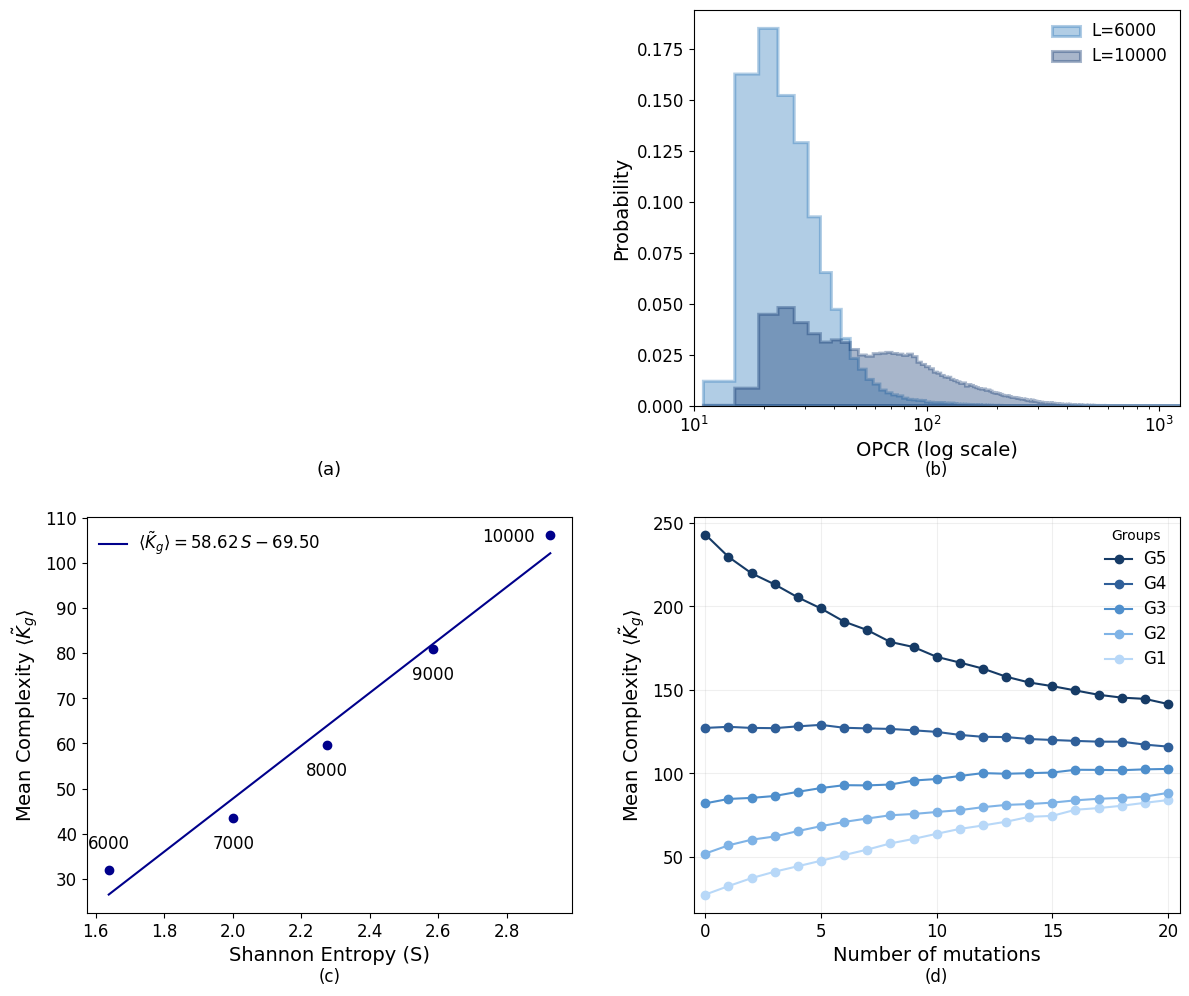

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ===================================
# Helper functions
# ===================================
def load_opc_freq(path):
    df = pd.read_csv(path, sep=r"\s+")
    df.columns = df.columns.str.strip()
    df = df[["OPC_value", "Frequency"]].copy()
    df["OPC_value"] = pd.to_numeric(df["OPC_value"], errors="coerce")
    df["Frequency"] = pd.to_numeric(df["Frequency"], errors="coerce")
    df = df.dropna()
    df = df[df["OPC_value"] > 0].copy()
    return df

def binned_prob_hist(df, bins, total):
    x = df["OPC_value"].to_numpy(dtype=float)
    w = df["Frequency"].to_numpy(dtype=float)
    counts, edges = np.histogram(x, bins=bins, weights=w)
    probs = counts / total if total > 0 else counts.astype(float)
    return probs, edges

# ===================================
# Figure layout: empty upper-left, plots in the rest
# ===================================
fig = plt.figure(figsize=(12, 10))
ax_blank = plt.subplot2grid((2, 2), (0, 0))
ax_top = plt.subplot2grid((2, 2), (0, 1))
ax_bl = plt.subplot2grid((2, 2), (1, 0))
ax_br = plt.subplot2grid((2, 2), (1, 1))

ax_blank.axis("off")

ax_blank.text(
    0.5, -0.14, "(a)",
    transform=ax_blank.transAxes,
    ha="center", va="top",
    fontsize=13
)

# ===================================
# Shared bin width for consistent logic
# ===================================
bin_width = 0.5

main_bins = np.arange(0, 30 + bin_width, bin_width)

# ===================================
# Main plots
# ===================================

plot_A(
    ax_top,
    #only base filtering
    file_6000="/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_a/filtered_6000_opc_cusp.txt",
    file_10000="/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_a/filtered_10000_opc_cusp.txt",    
    #removed frequency 1
    #file_2000="/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_a/filter_opcfreq1/filtered_2000_opc_cusp_nosingletons.txt",
    #file_6000="/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_a/filter_opcfreq1/filtered_6000_opc_cusp_nosingletons.txt",
    #file_10000="/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_a/filter_opcfreq1/filtered_10000_opc_cusp_nosingletons.txt",
    #removed frequency 3 and less 
    #file_2000="/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_a/filter_opc_freq3/filtered_2000_opc_cusp_min4.txt",
    #file_6000="/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_a/filter_opc_freq3/filtered_6000_opc_cusp_min4.txt",
    #file_10000="/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_a/filter_opc_freq3/filtered_10000_opc_cusp_min4.txt",
    bin_width=4.0,
)

plot_B(ax_bl, color="darkblue")
plot_C(ax_br)

# ===================================
# Labels and title
# ===================================
ax_top.text(0.5, -0.14, "(b)", transform=ax_top.transAxes, ha="center", va="top", fontsize=13)
ax_bl.text(0.5, -0.14, "(c)", transform=ax_bl.transAxes, ha="center", va="top", fontsize=13)
ax_br.text(0.5, -0.14, "(d)", transform=ax_br.transAxes, ha="center", va="top", fontsize=13)

# ===================================
# Styling
# ===================================
LABEL_SIZE = 14
TICK_SIZE = 12
LEGEND_SIZE = 12
ANNOT_SIZE = 12

for ax in [ax_top, ax_bl, ax_br]:
    ax.xaxis.label.set_size(LABEL_SIZE)
    ax.yaxis.label.set_size(LABEL_SIZE)
    ax.tick_params(labelsize=TICK_SIZE)

    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(LEGEND_SIZE)

    for text in ax.texts:
        text.set_fontsize(ANNOT_SIZE)

plt.tight_layout()
plt.subplots_adjust(hspace=0.28, wspace=0.25)
plt.show()

# ===================================
# Mean and median for each dataset
# ===================================

def weighted_stats(df):
    values = df["OPC_value"].to_numpy()
    weights = df["Frequency"].to_numpy()

    # Weighted mean
    mean = np.average(values, weights=weights)

    # Weighted median
    sorted_idx = np.argsort(values)
    values_sorted = values[sorted_idx]
    weights_sorted = weights[sorted_idx]

    cum_weights = np.cumsum(weights_sorted)
    cutoff = cum_weights[-1] / 2
    median = values_sorted[np.searchsorted(cum_weights, cutoff)]

    return mean, median

In [18]:
path_6000 = "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_a/filtered_6000_opc_cusp.txt"
path_10000 = "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_a/filtered_10000_opc_cusp.txt"

df_6000 = pd.read_csv(path_6000, sep=r"\s+")
df_10000 = pd.read_csv(path_10000, sep=r"\s+")

print("Mean OPC in file_6000:", df_6000["OPC"].mean())
print("Mean OPC in file_10000:", df_10000["OPC"].mean())

Mean OPC in file_6000: 32.08793353913202
Mean OPC in file_10000: 106.58461532244159


print how many unique OPC values and cusp numbers are in file_10000

In [19]:
print("Unique OPC values:", df["OPC"].nunique())
print("Unique CUSPS values:", df["CUSPS"].nunique())

#print the Unique CUSPS values to check if they are all the same or not
print("Unique CUSPS values:", df["CUSPS"].unique())

NameError: name 'df' is not defined

In [ ]:
import pandas as pd

path = "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_a/filtered_10000_opc_cusp.txt"

df = pd.read_csv(path, sep=r"\s+")

max_opc = df["OPC"].max()

print("Max OPC value:", max_opc)

Max OPC value: 1220.375


In [ ]:
import pandas as pd

path = "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_a/filtered_10000_opc_cusp.txt"

df = pd.read_csv(path, sep=r"\s+")

# number of OPC values
n_values = len(df["OPC"])

print("Number of OPC values:", n_values)

Number of OPC values: 92792


In [ ]:
import pandas as pd

path = "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_a/filtered_10000_opc_cusp.txt"

df = pd.read_csv(path, sep=r"\s+")

# count occurrences of each OPC value
counts = df["OPC"].value_counts()

# how many OPC values occur exactly once
n_singletons = (counts == 1).sum()

print("Number of OPC values occurring exactly once:", n_singletons)

Number of OPC values occurring exactly once: 547


Simplicity Bias Code

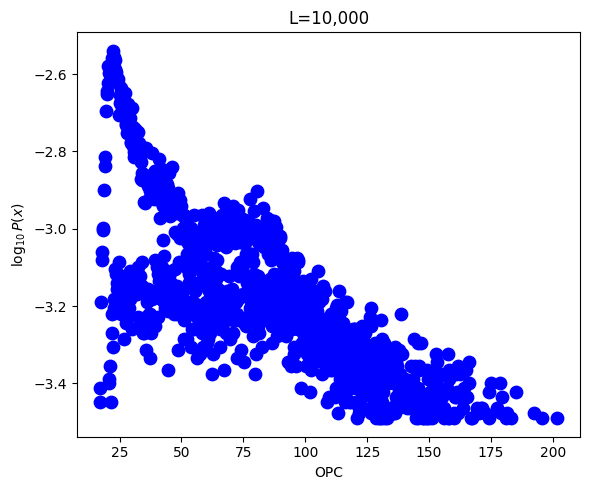

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Load data
# -----------------------------------
file_path = "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_a/filtered_10000_opc_cusp.txt"

df = pd.read_csv(file_path, sep=r"\t|,|\s+", engine="python")
df.columns = df.columns.str.strip()

# -----------------------------------
# Match the R logic
# -----------------------------------
# 1) remove rows with Cusps <= 0
df = df[df["CUSPS"] > 0].copy()

# 2) count occurrences of each OPC value
counts = df["OPC"].value_counts().sort_index()

x = counts.index.to_numpy()
n = counts.to_numpy()

# 3) log10 probability
freq = np.log10(n / n.sum())

# 4) keep only points with freq > -3.5
mask = freq > -3.5
x = x[mask]
freq = freq[mask]

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(6, 5))

plt.scatter(
    x,
    freq,
    s=80,
    alpha=1,
    color="blue"
)

plt.xlabel("OPC")
plt.title("L=10,000")
plt.ylabel(r"$\log_{10} P(x)$")

plt.tight_layout()
plt.show()

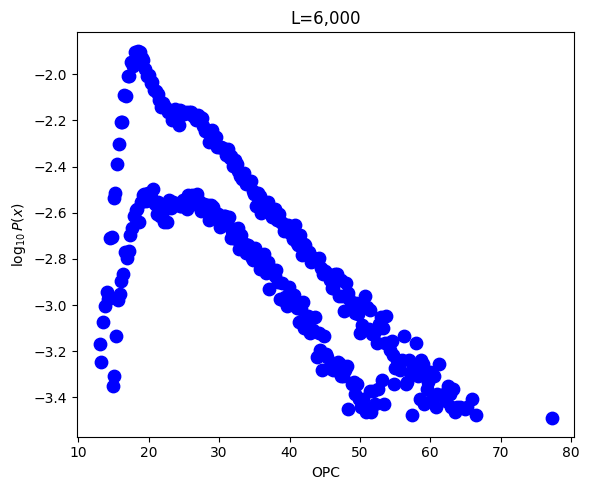

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Load data
# -----------------------------------
file_path = "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_a/filtered_6000_opc_cusp.txt"

df = pd.read_csv(file_path, sep=r"\t|,|\s+", engine="python")
df.columns = df.columns.str.strip()

# -----------------------------------
# Match the R logic
# -----------------------------------
# 1) remove rows with Cusps <= 0
df = df[df["CUSPS"] > 0].copy()

# 2) count occurrences of each OPC value
counts = df["OPC"].value_counts().sort_index()

x = counts.index.to_numpy()
n = counts.to_numpy()

# 3) log10 probability
freq = np.log10(n / n.sum())

# 4) keep only points with freq > -3.5
mask = freq > -3.5
x = x[mask]
freq = freq[mask]

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(6, 5))

plt.scatter(
    x,
    freq,
    s=80,
    alpha=1,
    color="blue"
)

plt.xlabel("OPC")
plt.title("L=6,000")
plt.ylabel(r"$\log_{10} P(x)$")

plt.tight_layout()
plt.show()

## Convergence?

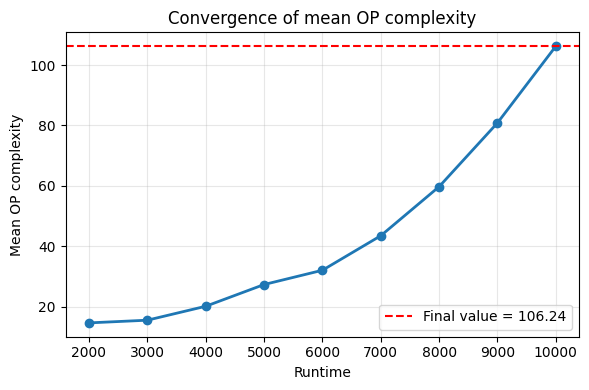

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Path to the data
base_dir = "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/tooth model/new_range/plot_b/plot_b_data"

# Sample sizes
sample_sizes = np.arange(2000, 10001, 1000)

# Read the mean OP complexity values
mean_opc = []

for n in sample_sizes:
    filename = os.path.join(base_dir, str(n), f"{n}_meanOpc.txt")
    value = float(np.loadtxt(filename))
    mean_opc.append(value)

mean_opc = np.array(mean_opc)

# Plot
import matplotlib.pyplot as plt
import numpy as np

# mean_opc and runtime should already have been loaded
runtime = sample_sizes  # rename for clarity

plt.figure(figsize=(6,4))

plt.plot(runtime, mean_opc, '-o', linewidth=2, markersize=6)

# Final value
plt.axhline(mean_opc[-1], color='red', linestyle='--',
            label=f'Final value = {mean_opc[-1]:.2f}')

plt.xlabel("Runtime")
plt.ylabel("Mean OP complexity")
plt.title("Convergence of mean OP complexity")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

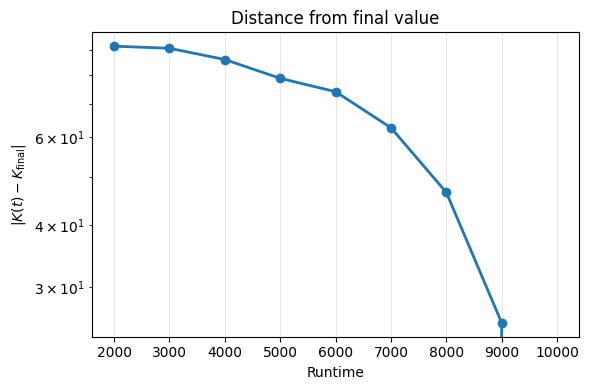

In [31]:
distance = np.abs(mean_opc - mean_opc[-1])

plt.figure(figsize=(6,4))

plt.plot(runtime, distance, '-o', linewidth=2, markersize=6)

plt.xlabel("Runtime")
plt.ylabel(r"$|K(t)-K_{\mathrm{final}}|$")
plt.title("Distance from final value")
plt.yscale("log")  # remove this if the values span less than about one order of magnitude
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

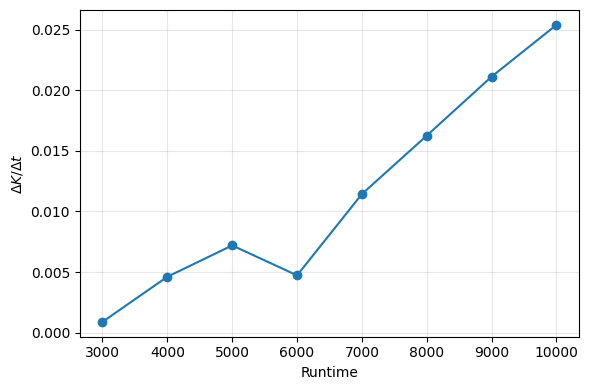

In [32]:
increments = np.diff(mean_opc) / 1000

plt.figure(figsize=(6,4))
plt.plot(runtime[1:], increments, '-o')

plt.xlabel("Runtime")
plt.ylabel(r"$\Delta K / \Delta t$")
plt.grid(alpha=0.3)
plt.tight_layout()

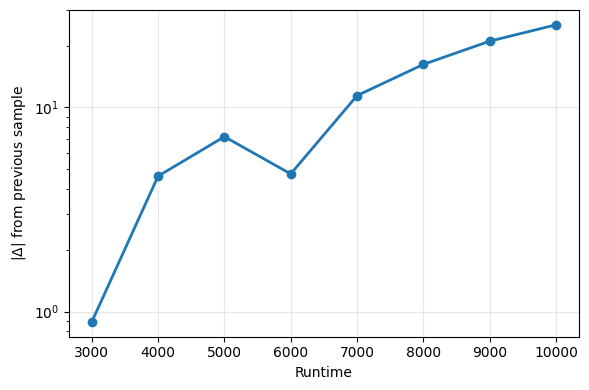

In [28]:
diffs = np.abs(np.diff(mean_opc))

plt.figure(figsize=(6,4))

plt.plot(sample_sizes[1:], diffs, '-o', lw=2)

plt.xlabel("Runtime")
plt.ylabel(r"$|\Delta|$ from previous sample")
plt.yscale("log")          # useful if convergence is rapid
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

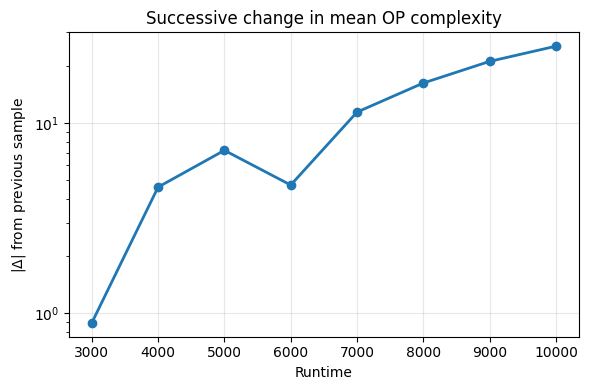

In [27]:
# Successive changes
delta = np.abs(np.diff(mean_opc))

plt.figure(figsize=(6,4))

plt.plot(sample_sizes[1:], delta, '-o', linewidth=2, markersize=6)

plt.xlabel("Runtime")
plt.ylabel(r"$|\Delta|$ from previous sample")
plt.yscale("log")
plt.title("Successive change in mean OP complexity")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()